# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# TODO: [Completa aquí] ¿Qué debes hacer con esta variable email?
email = '202645314@alu.comillas.edu'  # ⚠️ CAMBIAR POR TU EMAIL DE DATABRICKS

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    # TODO: [Completa aquí] ¿Para qué sirve set_tracking_uri?
    mlflow.set_tracking_uri("databricks")
    
    # TODO: [Completa aquí] ¿Qué hace set_experiment?
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

✅ MLflow configurado correctamente
📊 Experimento: /Users/202645314@alu.comillas.edu/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [0]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: [Completa aquí] ¿Para qué sirve train_test_split?
from sklearn.model_selection import train_test_split

# TODO: [Completa aquí] ¿Qué es un Pipeline en sklearn?
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# TODO: [Completa aquí] ¿Qué modelos vamos a usar?
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# TODO: [Completa aquí] ¿Para qué sirve cross_val_score?
from sklearn.model_selection import cross_val_score, cross_val_predict

# TODO: [Completa aquí] ¿Qué métricas usaremos y por qué?
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [0]:
# TODO: Carga los datos y explica qué contiene el archivo.
df = pd.read_csv("../data/raw/heart.csv")

# TODO: Muestra número de filas, columnas y variable objetivo.
print("Shape:", df.shape)
df["target"].value_counts()


Shape: (303, 14)


target
1    165
0    138
Name: count, dtype: int64

In [0]:
# TODO: Muestra las primeras filas con head().
# TODO: Explica por qué esta inspección es útil antes de modelar.

# data.head()
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [0]:
# TODO: Usa info() para revisar tipos de datos y valores nulos.
df.info()

# TODO: Anota qué columnas parecen categóricas y cuáles numéricas.
#   Those columns that are bjects are categorical. The columns that have int or float values are numerics.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 31.2+ KB


In [0]:
# TODO: Usa describe() para obtener estadísticas descriptivas.
df.describe()

# TODO: Escribe observaciones sobre rangos, medias y posibles valores atípicos.


,age,trestbps,chol,thalach,oldpeak,ca,thal,target
count,303.000000,258.000000,273.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.465116,245.871795,149.646865,1.039604,0.729373,2.313531,0.544554
std,9.082101,16.914317,52.528792,22.905161,1.161075,1.022606,0.612277,0.498835
min,29.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,209.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,3.000000,1.000000


### 💡 Observaciones Clave

**TODO: [Completa aquí] Basándote en las estadísticas, ¿qué observaciones puedes hacer sobre:**
- La edad media de los pacientes: The statistics represents only the older part of the population. We dont have data of kids or young people (under 29).
- El rango de valores de cada característica
- La presencia de valores nulos: There are some null values in the columns `trestbps` and `chol`.
- Características que pueden necesitar normalización

In [0]:
# TODO: Analiza la distribución de la variable objetivo.
target_counts = df.target.value_counts()
print(target_counts)

# TODO: Calcula proporciones por clase.
print("Proporción de target 0:", target_counts[0] / len(df))
print("Proporción de target 1:", target_counts[1] / len(df))
# TODO: Decide si el dataset está balanceado y explica por qué importa.


target
1    165
0    138
Name: count, dtype: int64
Proporción de target 0: 0.45544554455445546
Proporción de target 1: 0.5445544554455446


### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

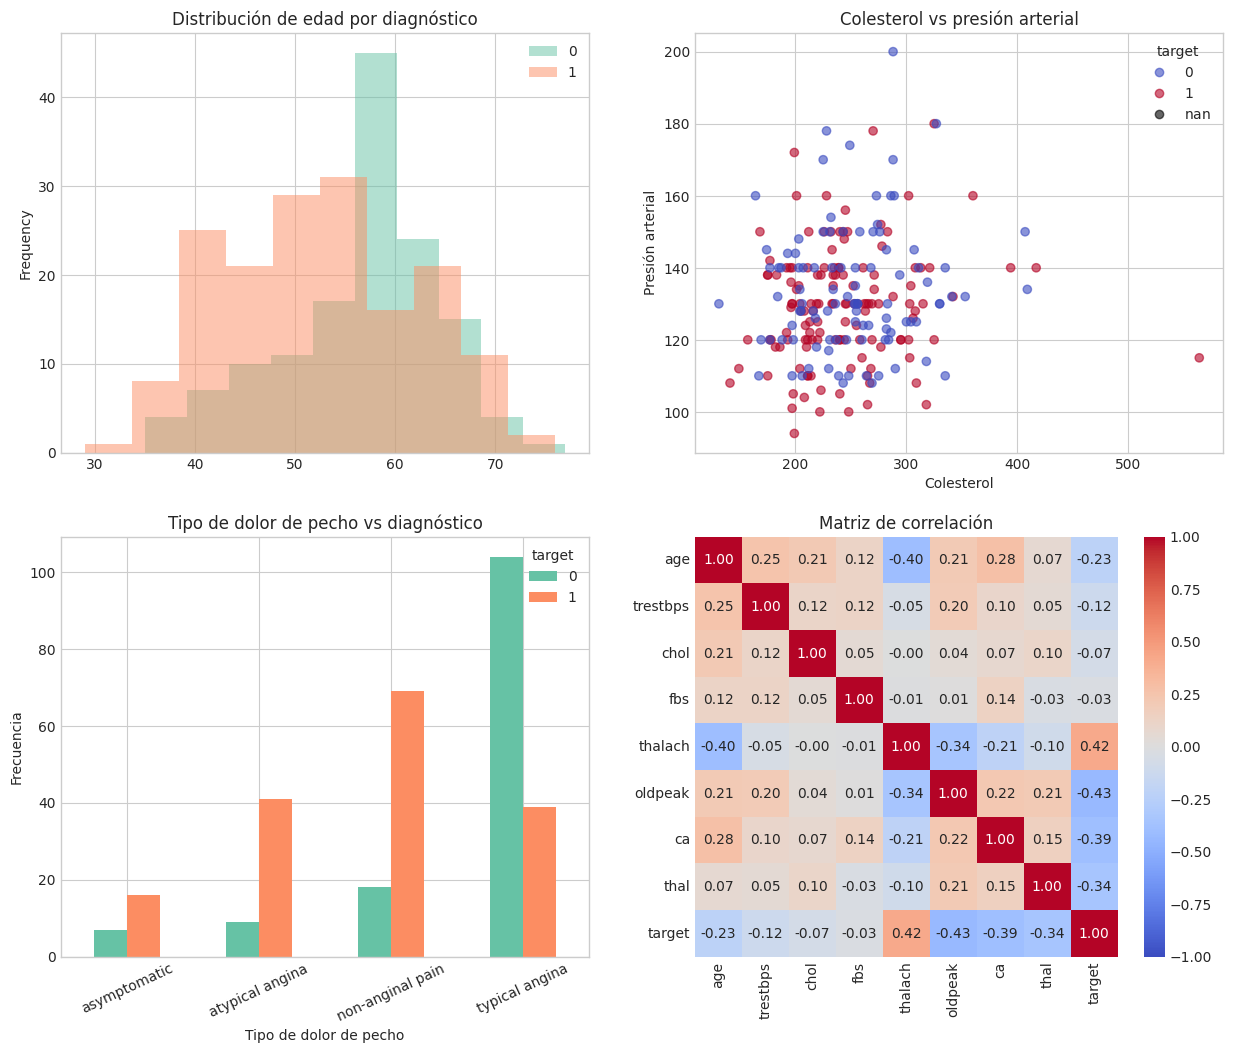

In [0]:
# TODO: Crea visualizaciones para explorar patrones del dataset.
# Ideas:
# - Distribución de edad por diagnóstico
# - Colesterol vs presión arterial coloreado por target
# - Tipo de dolor de pecho vs diagnóstico
# - Matriz de correlación

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].set_title("Distribución de edad por diagnóstico")
df.groupby("target")["age"].plot.hist(alpha=0.5, legend=True, ax=axes[0, 0])


sc = axes[0, 1].scatter(df["chol"], df["trestbps"], c=df["target"], cmap="coolwarm", alpha=0.6)
axes[0, 1].set_title("Colesterol vs presión arterial")
axes[0, 1].set_xlabel("Colesterol")
axes[0, 1].set_ylabel("Presión arterial")
axes[0, 1].legend(*sc.legend_elements(), title="target")

pd.crosstab(df["cp"], df["target"]).plot.bar(ax=axes[1, 0], rot=25)
axes[1, 0].set_title("Tipo de dolor de pecho vs diagnóstico")
axes[1, 0].set_xlabel("Tipo de dolor de pecho")
axes[1, 0].set_ylabel("Frecuencia")


sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title("Matriz de correlación")

plt.show()


# TODO: Escribe qué patrones observas en los gráficos.


## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Divide los datos en train y test.
# Pistas:
# - Usa train_test_split
# - Define test_size
# - Usa random_state para reproducibilidad

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=y)

# TODO: Comprueba el tamaño de cada conjunto.

train_set.shape, test_set.shape

((242, 14), (61, 14))

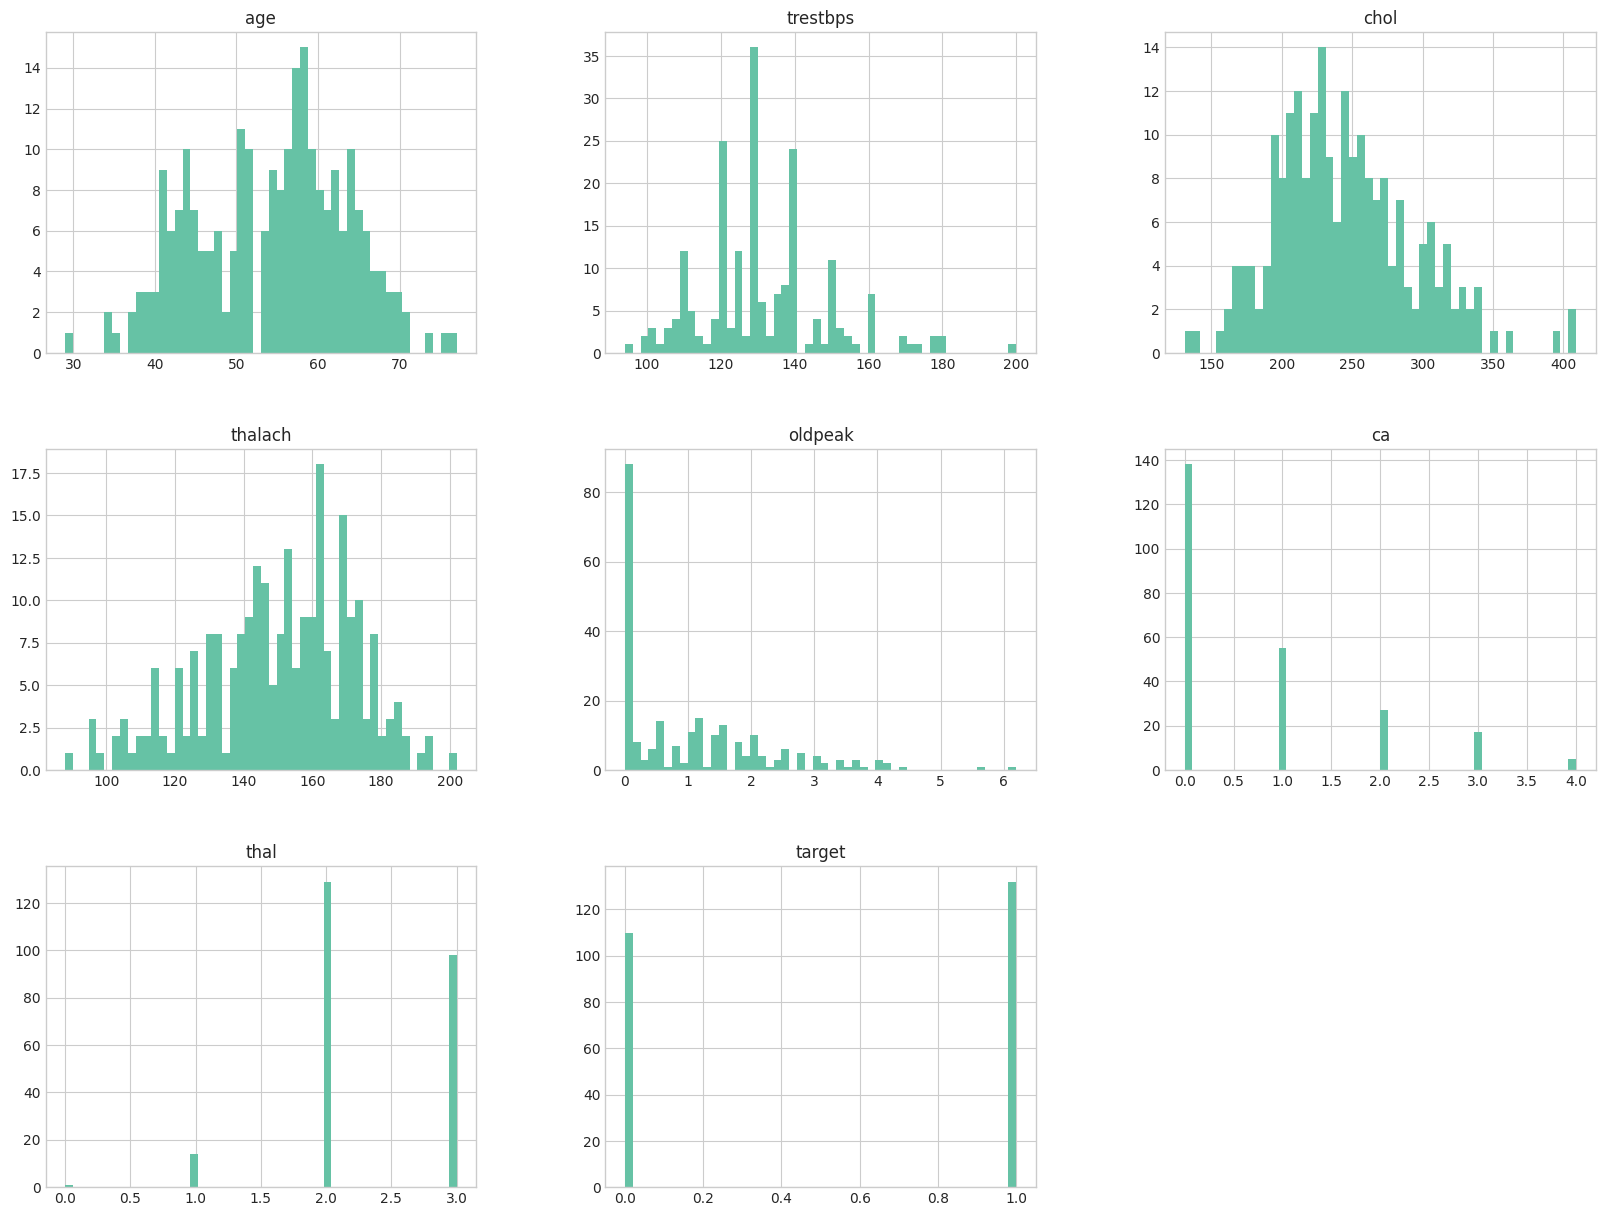

In [0]:
# TODO: Genera histogramas del conjunto de entrenamiento.
train_set.hist(bins=50, figsize=(20, 15))
plt.show()

# TODO: Identifica características con escalas o distribuciones muy diferentes.


### 📏 Observación Importante: Escalas Diferentes

**TODO: [Completa aquí] ¿Por qué es un problema que las características tengan escalas diferentes?**

Revisa columnas como `age`, `trestbps`, `chol`, `thalach` y `oldpeak`.

Porque las variables más grandes, dependiendo del modelo que se utilice, pueden tener más peso sin tener que ser propiamente más relevantes.

**TODO: [Completa aquí] ¿Qué transformación aplicarías para que las variables numéricas sean comparables?**

Estandarizarlas todas con StandardScaler. 

**TODO: [Completa aquí] ¿Por qué esto ayuda a algunos modelos de Machine Learning?**

De esta manera, todas las variables contribuirán lo mismo a la hora de predecir los valores.


## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [0]:
# TODO: Clasifica las columnas en categóricas y numéricas.
cat_attr = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
num_attr = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

# TODO: Crea un pipeline para variables numéricas.
# Pistas:
# - SimpleImputer para valores nulos
# - StandardScaler para estandarizar
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# TODO: Crea un ColumnTransformer que combine numéricas y categóricas.
# Pista: usa OneHotEncoder para variables categóricas.
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attr),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attr),
])



# TODO: Explica por qué usamos One-Hot Encoding para categóricas.
# Because these variables do not have any order. So using 1,2,3... to describe them is telling the model that they are ordered. But they are not.

## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [0]:
# TODO: Separa características (X) y target (y) del conjunto de entrenamiento.
X_train = train_set.drop(columns="target")
y_train = train_set["target"]

# TODO: Comprueba las dimensiones resultantes.
X_train.shape, y_train.shape

((242, 13), (242,))

In [0]:
# TODO: Aplica el pipeline al conjunto de entrenamiento.
X_train_pr = full_pipeline.fit_transform(X_train)

# TODO: Explica la diferencia entre fit_transform y transform.
# fit: learn mean, std... from the data
# transform: applied the learned values to transform the data
# fit_transform: do both of them 
# TODO: Comprueba cómo cambia el número de columnas.
X_train_pr.shape


(242, 26)

## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

**TODO: [Completa aquí] ¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?**

Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [0]:
# TODO: Activa autolog de MLflow.
mlflow.sklearn.autolog()

# TODO: Inicia un run para el modelo baseline SGD.
with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
#     TODO: Crea SGDClassifier.
    sgd_clf = SGDClassifier(random_state=42)
#
#     TODO: Evalúa con cross_val_score.
    scores = cross_val_score(sgd_clf, X_train_pr, y_train, cv=5, scoring="accuracy")
#
#     TODO: Registra métricas de validación cruzada en MLflow.
    mlflow.log_param("model", "SGDClassifier")
    mlflow.log_param("cv", 5)
    mlflow.log_metric("cv_accuracy_mean", scores.mean())
    mlflow.log_metric("cv_accuracy_std", scores.std())
#
#     TODO: Interpreta el resultado obtenido.


2026/10/02 11:22:59 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 11:22:59 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 11:22:59 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 11:22:59 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-82e64892-4b54.cloud.databricks.com/ml/experiments/2809317422214768/models/m-f200e268487546109715f1c6782bf656?o=7474648796184508
2026/10/02 11:23:06 WARNING mlflow.t

### 📊 Evaluación del Modelo SGD

In [0]:
# TODO: Obtén predicciones con validación cruzada.
preds = cross_val_predict(sgd_clf, X_train_pr, y_train, cv=5)

# TODO: Explica por qué cross_val_predict es útil para construir métricas y matriz de confusión.
# It does the same as cross_val_score, but returns more information. Whit this information, you can build the confusion matrix and other metrics.


2026/10/02 11:29:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 11:29:11 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '31a0b64272014ae092d5f3e576a58742', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/02 11:29:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 11:29:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 11:29:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a Co

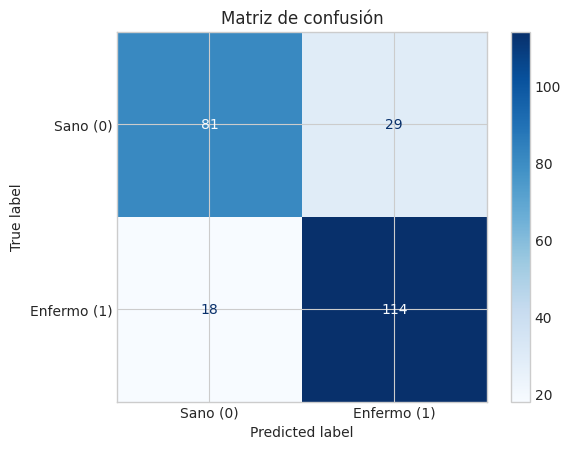

TN=81, FP=29, FN=18, TP=114


In [0]:
# TODO: Calcula y visualiza la matriz de confusión del modelo SGD.

cm = confusion_matrix(y_train, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sano (0)", "Enfermo (1)"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# TODO: Interpreta TN, FP, FN y TP.
# TODO: ¿Qué tipo de error es más grave en medicina?
# FN is more grave because it means that the patient is sick, but the model is returning that he is healthy.


In [0]:
# TODO: Calcula métricas del modelo SGD.
precision = precision_score(y_train, preds)
recall = recall_score(y_train, preds)
f1 = f1_score(y_train, preds)
roc_auc = roc_auc_score(y_train, preds)

# TODO: Imprime e interpreta las métricas.

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

# TODO: ¿Qué métrica es más importante en medicina y por qué?
# Recall, because it measures the TP. The others are FN.


Precision: 0.797
Recall:    0.864
F1:        0.829
ROC-AUC:   0.800


### 🌲 Modelo 2: Random Forest Classifier

**TODO: [Completa aquí] ¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?**

Ahora probemos un modelo más potente y comparemos resultados.

In [0]:
# TODO: Entrena y evalúa un Random Forest en un nuevo run de MLflow.
with mlflow.start_run(run_name="Random Forest Classifier") as run:
    rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

    rf_scores = cross_val_score(rf_clf, X_train_pr, y_train, cv=5, scoring="accuracy")
    rf_preds = cross_val_predict(rf_clf, X_train_pr, y_train, cv=5)

    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("cv_accuracy_mean", rf_scores.mean())
    mlflow.log_metric("cv_accuracy_std", rf_scores.std())
#
# TODO: Explica qué hiperparámetros podrías ajustar y por qué comparas contra SGD.
# RandomForest allows to adjust the n_estimators. We need to compare it with SGD because it is a more complex model, so if it does not returns better results, we wont use it.


2026/10/02 11:40:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 11:40:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 11:40:58 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 11:40:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-82e64892-4b54.cloud.databricks.com/ml/experiments/2809317422214768/models/m-60ded05ea02f4339afb50d7533fff53f?o=7474648796184508
2026/10/02 11:41:03 WARNING mlflow.t

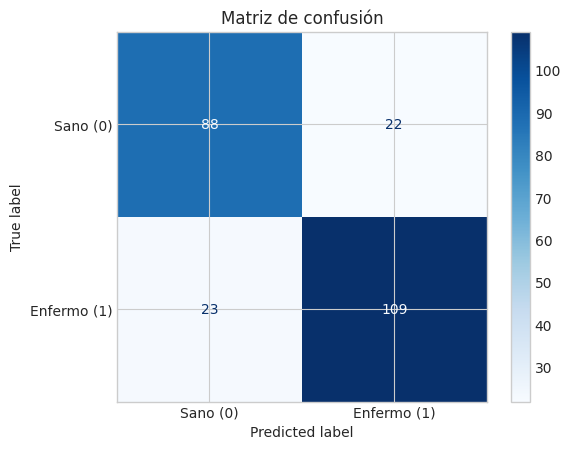

TN=88, FP=22, FN=23, TP=109


In [0]:
# TODO: Calcula y visualiza la matriz de confusión de Random Forest.
cm_rf = confusion_matrix(y_train, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Sano (0)", "Enfermo (1)"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# TODO: Compara los errores con los del modelo SGD.


In [0]:
# TODO: Calcula métricas de Random Forest.
precision = precision_score(y_train, rf_preds)
recall = recall_score(y_train, rf_preds)
f1 = f1_score(y_train, rf_preds)
roc_auc = roc_auc_score(y_train, rf_preds)

# TODO: Imprime e interpreta las métricas.

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

# TODO: Crea una tabla comparativa SGD vs Random Forest.
# TODO: Decide qué modelo funciona mejor y justifica tu respuesta.
# SGD is a better model, because it has a higher recall, that in this example, is more important than precision.



Precision: 0.832
Recall:    0.826
F1:        0.829
ROC-AUC:   0.813


## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [0]:
# TODO: Entrena el modelo final usando todo el conjunto de entrenamiento procesado.
# forest_clf = RandomForestClassifier(...)
# forest_clf.fit(...)


forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
forest_clf.fit(X_train_pr, y_train)

# TODO: Explica por qué ahora entrenamos con todos los datos de train.


2026/10/02 11:50:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 11:50:46 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '26d36a3979334009a79267fa211245f8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/02 11:50:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 11:50:46 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 11:50:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a Co

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [0]:
# TODO: Separa características y target del conjunto de prueba.
X_test = test_set.drop(columns="target")
y_test = test_set["target"]

# TODO: Comprueba dimensiones.
X_test.shape, y_test.shape


((61, 13), (61,))

In [0]:
# TODO: Transforma el conjunto de prueba y genera predicciones.
X_test_pr = full_pipeline.transform(X_test)
final_preds = forest_clf.predict(X_test_pr)

# TODO: Explica por qué usamos transform() y no fit_transform() en test.
# Because the pipeline already has the fit_transform() method applied. If we fit again, we may get different results.


2026/10/02 11:52:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


Precision: 0.757
Recall:    0.848
F1:        0.800
ROC-AUC:   0.764


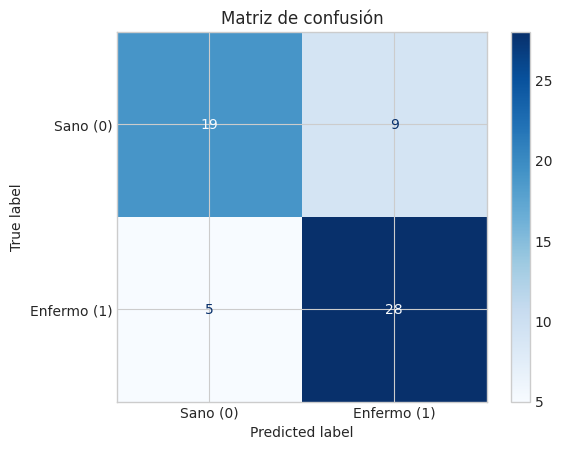

TN=19, FP=9, FN=5, TP=28
              precision    recall  f1-score   support

    Sano (0)       0.79      0.68      0.73        28
 Enfermo (1)       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61



In [0]:
# TODO: Evalúa resultados finales en el conjunto de prueba.

final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_preds)

# TODO: Imprime e interpreta las métricas.

print(f"Precision: {final_precision:.3f}")
print(f"Recall:    {final_recall:.3f}")
print(f"F1:        {final_f1:.3f}")
print(f"ROC-AUC:   {final_roc_auc:.3f}")

# TODO: Visualiza la matriz de confusión final.

cm_rf = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Sano (0)", "Enfermo (1)"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# TODO: Genera classification_report.
print(classification_report(y_test, final_preds, target_names=["Sano (0)", "Enfermo (1)"]))
# TODO: Interpreta si el modelo generaliza bien.
# The model is working well. It is true that there are some FN, but the model is predicting correctly most of the time. For example, it could be used to conduct mass population screening and improve the efficiency of healthcare centers.


## 🎉 Reflexión Final del Proyecto

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración de datos médicos reales
2. [ ] Pipeline de preprocesamiento
3. [ ] Entrenamiento y comparación de modelos
4. [ ] Evaluación con métricas de clasificación
5. [ ] Validación cruzada
6. [ ] Registro de experimentos en MLflow
7. [ ] Interpretación de resultados con matrices de confusión

### 📊 Conclusiones Clave

**TODO: Basándote en tus resultados, escribe tus conclusiones:**

1. **¿Qué modelo funcionó mejor?**
   - El modelo más simple fue el que funcionó mejor. A pesar de que los resultados de ambos modelos fueron parecidos, no se aprecia una diferencia tan importante como para complicar el modelo utilizando RandomTrees

2. **¿Por qué crees que funcionó mejor?**
   - Posiblemente porque con los datos existentes, no se podían sacar mejores métricas, aunque el algoritmo sea mejor. Sería necesario obtener mejores y más datos.

3. **¿El modelo es suficientemente bueno para uso médico?**
   - Sí, pero no para un uso individual. Sin embargo, sería util para realizar cribados masivos a la población, y poner detectar de manera muy rápida la gran mayoría de Verdaderos Positivos (TP).

4. **¿Qué métrica es más importante en este caso?**
   - El recall. Permite medir los FN, es decir, los casos que aun estando enfermos, han dado Negativo. Estos casos deberían de acercarse a 0.

5. **¿Qué mejorarías del modelo?**
   - Se necesitan más datos para aumentar el recall.

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina e IA

**TODO: Reflexiona sobre:**

1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   - Falsos Negativos. Es importante que todos los enfermos sean detectados. Sin embargo, también se deben tener en cuenta los Falsos Positivos: un modelo que afirme que todos son enfermos, tendría un recall de 1.0

2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - Este modelo desde luego que no. Desconozco la capacidad que tienen el resto de modelos existentes en el mercado. Sin embargo, no cabe duda en que sirven de gran ayuda. 

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - Porque los responsables a día de hoy son ellos. Por lo tanto, tienen que saber explicar porque el modelo comete fallos, y que fallos comete.

---

### 🚀 Desafíos Adicionales

1. **Optimización de Hiperparámetros** con `GridSearchCV`.
2. **Prueba Otros Modelos** como Gradient Boosting, SVM o Logistic Regression.
3. **Feature Engineering** para crear o seleccionar características.
4. **Análisis de Errores** para entender pacientes mal clasificados.
5. **Curva ROC** para comparar thresholds y AUC.


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del proyecto.

# ========================================
# TODO: DESAFÍO 1 - Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# param_grid = {...}
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

# ========================================
# TODO: DESAFÍO 2 - Curva ROC
# ========================================
# from sklearn.metrics import roc_curve, auc
# y_proba = ...
# fpr, tpr, thresholds = roc_curve(...)
# TODO: visualiza la curva ROC.

# ========================================
# TODO: DESAFÍO 3 - Importancia de características
# ========================================
# feature_names = ...
# feature_importance = ...
# TODO: identifica e interpreta las características más importantes.

# ========================================
# TODO: DESAFÍO 4 - Comparar más modelos
# ========================================
# modelos = {...}
# resultados = []
# for nombre, modelo in modelos.items():
#     # Entrena, evalúa y registra cada modelo en MLflow
#     pass
